In [1]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Modules imported successfully.


In [2]:
X_train = np.array([[0.0], [0.5], [1.0]])
y_func = np.sin(X_train)
y_deriv1 = np.cos(X_train)
y_train = [y_func, y_deriv1]

print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[0. ]
 [0.5]
 [1. ]]
y_train: [array([[0.        ],
       [0.47942554],
       [0.84147098]]), array([[1.        ],
       [0.87758256],
       [0.54030231]])]


In [3]:
der_indices = [[[[1, 1]]]]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]]]]


In [4]:
model = degp(X_train, y_train, n_order=1, n_bases=1,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("DEGP model initialized.")

DEGP model initialized.


In [5]:
params =  model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [-0.79639884  0.90022765 -8.7242228 ]


In [6]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)
y_func_pred = y_train_pred[:len(X_train)]
y_deriv_pred = y_train_pred[len(X_train):]

abs_error_func = np.abs(y_func_pred.flatten() - y_func.flatten())
abs_error_deriv = np.abs(y_deriv_pred.flatten() - y_deriv1.flatten())

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (derivative) at training points:", abs_error_deriv)

Absolute error (function) at training points: [5.50759438e-12 2.55462318e-12 5.35349542e-12]
Absolute error (derivative) at training points: [1.52300395e-12 7.09765580e-13 1.20470300e-12]


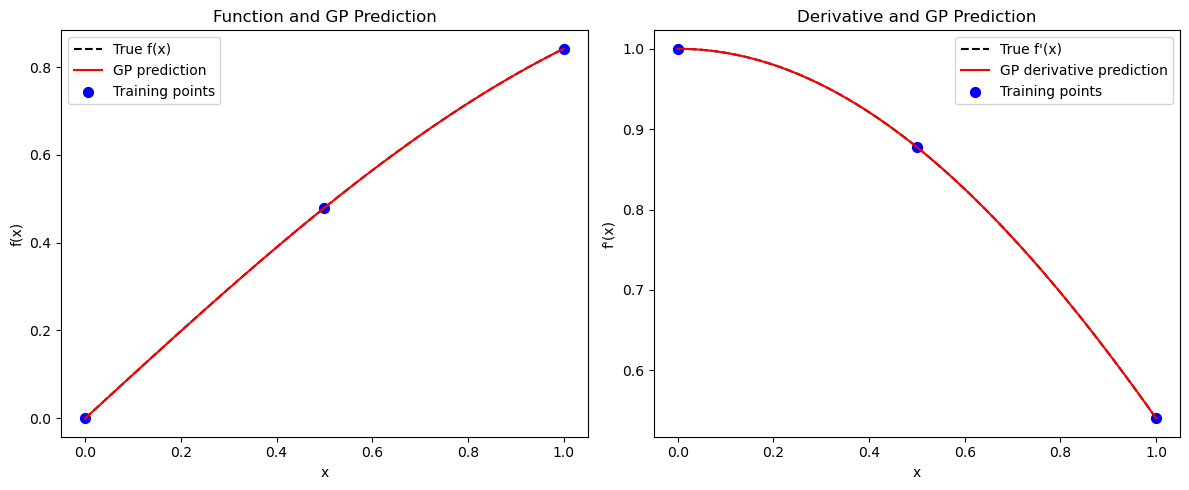

In [7]:
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

y_func_test = y_test_pred[:len(X_test)]
y_deriv_test = y_test_pred[len(X_test):]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(X_test, np.sin(X_test), 'k--', label='True f(x)')
plt.plot(X_test, y_func_test, 'r-', label='GP prediction')
plt.scatter(X_train, y_func, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function and GP Prediction')
plt.legend()

plt.subplot(1,2,2)
plt.plot(X_test, np.cos(X_test), 'k--', label="True f'(x)")
plt.plot(X_test, y_deriv_test, 'r-', label='GP derivative prediction')
plt.scatter(X_train, y_deriv1, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Derivative and GP Prediction')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
X_train = np.array([[0.0], [0.5], [1.0]])
y_func = np.sin(X_train)
y_deriv1 = np.cos(X_train)
y_deriv2 = -np.sin(X_train)
y_train = [y_func, y_deriv1, y_deriv2]

print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[0. ]
 [0.5]
 [1. ]]
y_train: [array([[0.        ],
       [0.47942554],
       [0.84147098]]), array([[1.        ],
       [0.87758256],
       [0.54030231]]), array([[-0.        ],
       [-0.47942554],
       [-0.84147098]])]


In [9]:
der_indices = [[[[1, 1]], [[1, 2]]]]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]], [[1, 2]]]]


In [10]:
model = degp(X_train, y_train, n_order=2, n_bases=1,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("DEGP model (2nd order) initialized.")

DEGP model (2nd order) initialized.


In [11]:
params = model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = True
     )
print("Optimized hyperparameters:", params)

New best for swarm at iteration 1: [ -0.51141699   0.2685204  -10.35707546] -8.353595171623999
Best after iteration 1: [ -0.51141699   0.2685204  -10.35707546] -8.353595171623999
Best after iteration 2: [ -0.51141699   0.2685204  -10.35707546] -8.353595171623999
New best for swarm at iteration 3: [ -0.72640129   1.3537834  -11.65929076] -9.867242730600475
New best for swarm at iteration 3: [ -0.88519363   1.48760265 -10.23083328] -13.443598040410825
Best after iteration 3: [ -0.88519363   1.48760265 -10.23083328] -13.443598040410825
New best for swarm at iteration 4: [ -0.6821772    0.54906855 -10.0091504 ] -13.610231356194577
Best after iteration 4: [ -0.6821772    0.54906855 -10.0091504 ] -13.610231356194577
New best for swarm at iteration 5: [-0.7744359   1.03237621 -9.33765885] -14.173107118957327
New best for swarm at iteration 5: [ -0.79375016   0.73936445 -11.53884723] -15.008839023240794
Best after iteration 5: [ -0.79375016   0.73936445 -11.53884723] -15.008839023240794
Best a

Best after iteration 14: [ -0.80809463   0.89580271 -11.0832369 ] -16.07938599124593


Local optimization did not improve:
Best after iteration 15: [ -0.80809463   0.89580271 -11.0832369 ] -16.07938599124593
Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ -0.80809463   0.89580271 -11.0832369 ]


In [12]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

n_train = len(X_train)
y_func_pred = y_train_pred[:n_train]
y_deriv1_pred = y_train_pred[n_train:2*n_train]
y_deriv2_pred = y_train_pred[2*n_train:]

abs_error_func = np.abs(y_func_pred.flatten() - y_func.flatten())
abs_error_deriv1 = np.abs(y_deriv1_pred.flatten() - y_deriv1.flatten())
abs_error_deriv2 = np.abs(y_deriv2_pred.flatten() - y_deriv2.flatten())

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (1st derivative) at training points:", abs_error_deriv1)
print("Absolute error (2nd derivative) at training points:", abs_error_deriv2)

Absolute error (function) at training points: [2.14762158e-09 2.01088834e-09 6.80470036e-09]
Absolute error (1st derivative) at training points: [1.43564383e-10 3.84029586e-10 9.22256382e-10]
Absolute error (2nd derivative) at training points: [4.66412879e-10 9.77893266e-10 2.96184188e-11]


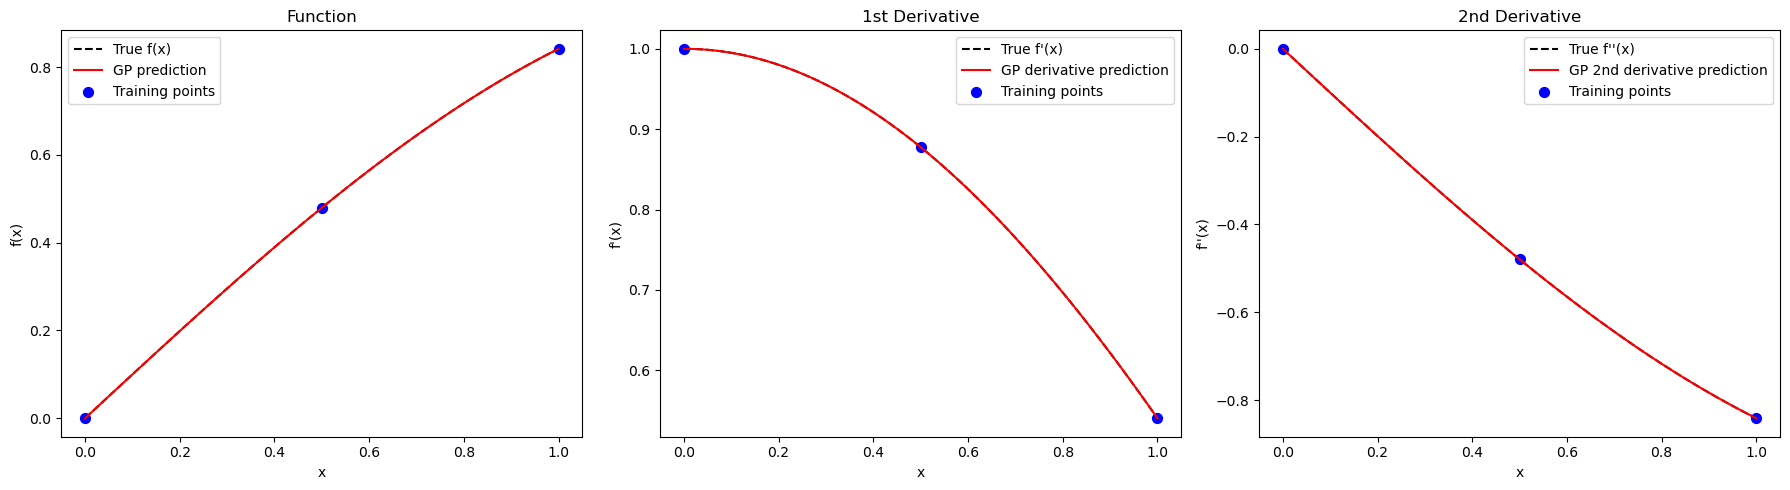

In [13]:
X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)

n_test = len(X_test)
y_func_test = y_test_pred[:n_test]
y_deriv1_test = y_test_pred[n_test:2*n_test]
y_deriv2_test = y_test_pred[2*n_test:]

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(X_test, np.sin(X_test), 'k--', label='True f(x)')
plt.plot(X_test, y_func_test, 'r-', label='GP prediction')
plt.scatter(X_train, y_func, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function')
plt.legend()

plt.subplot(1,3,2)
plt.plot(X_test, np.cos(X_test), 'k--', label="True f'(x)")
plt.plot(X_test, y_deriv1_test, 'r-', label='GP derivative prediction')
plt.scatter(X_train, y_deriv1, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('1st Derivative')
plt.legend()

plt.subplot(1,3,3)
plt.plot(X_test, -np.sin(X_test), 'k--', label="True f''(x)")
plt.plot(X_test, y_deriv2_test, 'r-', label='GP 2nd derivative prediction')
plt.scatter(X_train, y_deriv2, c='b', s=50, label='Training points')
plt.xlabel('x')
plt.ylabel("f''(x)")
plt.title('2nd Derivative')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Modules imported successfully for 2D example.")

Modules imported successfully for 2D example.


In [15]:
X1 = np.array([0.0, 0.5, 1.0])
X2 = np.array([0.0, 0.5, 1.0])
X1_grid, X2_grid = np.meshgrid(X1, X2)
X_train = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])

y_func = np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_x = np.cos(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_y = -np.sin(X_train[:,0]) * np.sin(X_train[:,1])
y_train = [y_func.reshape(-1,1), y_deriv_x.reshape(-1,1), y_deriv_y.reshape(-1,1)]

print("X_train shape:", X_train.shape)
print("y_train shapes:", [v.shape for v in y_train])

X_train shape: (9, 2)
y_train shapes: [(9, 1), (9, 1), (9, 1)]


In [16]:
der_indices = [[[[1, 1]], [[2, 1]]]]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]], [[2, 1]]]]


In [17]:
model = degp(X_train, y_train, n_order=1, n_bases=2,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("2D DEGP model initialized.")

2D DEGP model initialized.


In [18]:
params = model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ -0.66633162  -0.7337925    0.81890305 -12.85289224]


In [19]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

n_train = len(X_train)
y_func_pred = y_train_pred[:n_train]
y_deriv_x_pred = y_train_pred[n_train:2*n_train]
y_deriv_y_pred = y_train_pred[2*n_train:]

print("Predictions at training points (function):", y_func_pred)
print("Predictions at training points (deriv x):", y_deriv_x_pred)
print("Predictions at training points (deriv y):", y_deriv_y_pred)

Predictions at training points (function): [[ 4.99233987e-12]
 [ 4.79425539e-01]
 [ 8.41470985e-01]
 [-1.00942421e-10]
 [ 4.20735492e-01]
 [ 7.38460263e-01]
 [ 8.79024631e-12]
 [ 2.59034724e-01]
 [ 4.54648713e-01]]
Predictions at training points (deriv x): [[1.        ]
 [0.87758256]
 [0.54030231]
 [0.87758256]
 [0.77015115]
 [0.47415988]
 [0.54030231]
 [0.47415988]
 [0.29192658]]
Predictions at training points (deriv y): [[-1.36221846e-11]
 [-8.30621014e-12]
 [ 4.65147768e-12]
 [-1.32899362e-11]
 [-2.29848847e-01]
 [-4.03422680e-01]
 [-1.62801719e-11]
 [-4.03422680e-01]
 [-7.08073418e-01]]


In [20]:
abs_error_func = np.abs(y_func_pred.flatten() - y_func)
abs_error_dx = np.abs(y_deriv_x_pred.flatten() - y_deriv_x)
abs_error_dy = np.abs(y_deriv_y_pred.flatten() - y_deriv_y)

print("Absolute error (function) at training points:", abs_error_func)
print("Absolute error (deriv x) at training points:", abs_error_dx)
print("Absolute error (deriv y) at training points:", abs_error_dy)

Absolute error (function) at training points: [4.99233987e-12 5.50839374e-11 3.57552876e-11 1.00942421e-10
 6.48080478e-11 5.95133942e-11 8.79024631e-12 5.18064480e-11
 1.14142529e-10]
Absolute error (deriv x) at training points: [4.53805882e-11 5.16109377e-12 2.02164951e-11 5.99165162e-12
 4.17577084e-12 2.44020915e-11 3.17803561e-11 6.46316334e-13
 1.49421586e-11]
Absolute error (deriv y) at training points: [1.36221846e-11 8.30621014e-12 4.65147768e-12 1.32899362e-11
 3.05558079e-11 1.19315113e-11 1.62801719e-11 3.02051717e-11
 6.34789998e-11]


In [21]:
x1_test = np.linspace(0, 1, 50)
x2_test = np.linspace(0, 1, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.flatten(), X2_test.flatten()])

y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)
n_test = len(X_test)

y_func_test = y_test_pred[:n_test].reshape(50,50)
y_deriv_x_test = y_test_pred[n_test:2*n_test].reshape(50,50)
y_deriv_y_test = y_test_pred[2*n_test:].reshape(50,50)

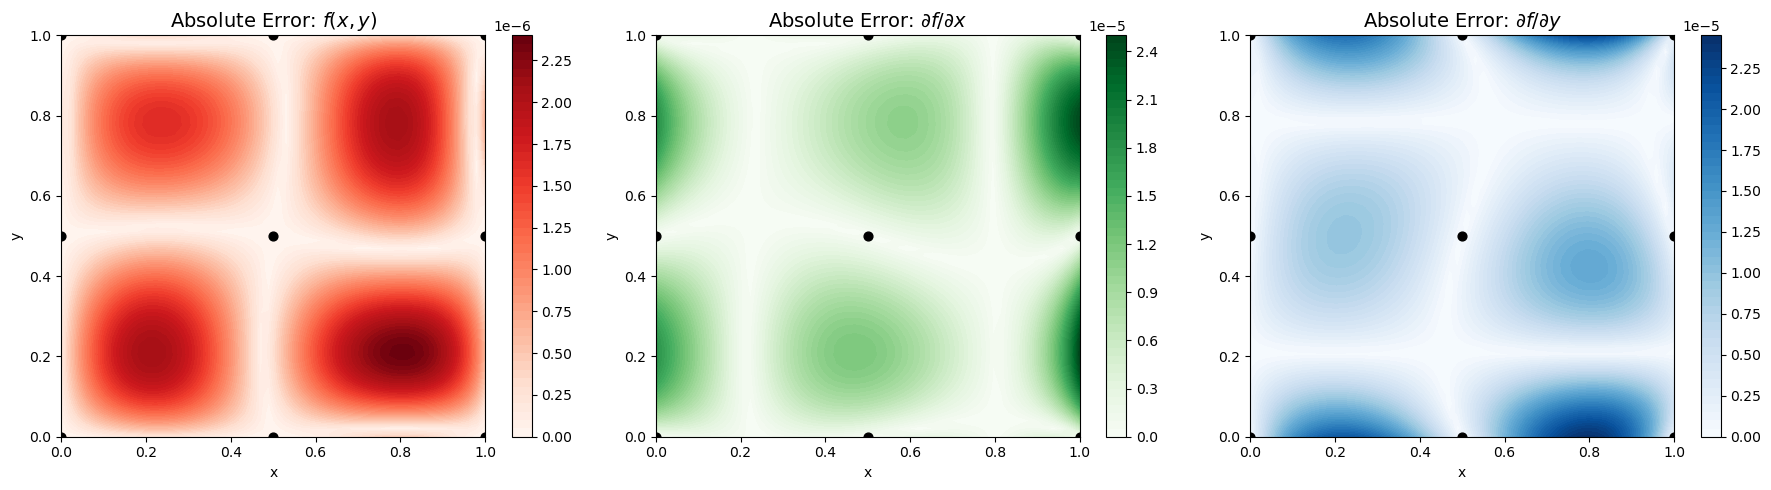

In [22]:
import matplotlib.pyplot as plt

# Compute absolute errors for function and first derivatives
abs_error_func = np.abs(y_func_test - (np.sin(X1_test) * np.cos(X2_test)))
abs_error_dx   = np.abs(y_deriv_x_test - (np.cos(X1_test) * np.cos(X2_test)))
abs_error_dy   = np.abs(y_deriv_y_test - (-np.sin(X1_test) * np.sin(X2_test)))

# Setup figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Titles and error arrays
titles = [
   r'Absolute Error: $f(x,y)$',
   r'Absolute Error: $\partial f / \partial x$',
   r'Absolute Error: $\partial f / \partial y$'
]
errors = [abs_error_func, abs_error_dx, abs_error_dy]
cmaps  = ['Reds', 'Greens', 'Blues']

# Plot each contour
for ax, err, title, cmap in zip(axs, errors, titles, cmaps):
   cs = ax.contourf(X1_test, X2_test, err, levels=50, cmap=cmap)
   ax.scatter(X_train[:,0], X_train[:,1], c='k', s=40)
   ax.set_title(title, fontsize=14)
   ax.set_xlabel('x')
   ax.set_ylabel('y')
   fig.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Modules imported successfully for 2D example with second-order derivatives.")

Modules imported successfully for 2D example with second-order derivatives.


In [24]:
X1 = np.array([0.0, 0.5, 1.0])
X2 = np.array([0.0, 0.5, 1.0])
X1_grid, X2_grid = np.meshgrid(X1, X2)
X_train = np.column_stack([X1_grid.flatten(), X2_grid.flatten()])

# True function and derivatives
y_func = np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_x = np.cos(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_y = -np.sin(X_train[:,0]) * np.sin(X_train[:,1])
y_deriv_xx = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])
y_deriv_yy = -np.sin(X_train[:,0]) * np.cos(X_train[:,1])

y_train = [
   y_func.reshape(-1,1),
   y_deriv_x.reshape(-1,1),
   y_deriv_y.reshape(-1,1),
   y_deriv_xx.reshape(-1,1),
   y_deriv_yy.reshape(-1,1)
]

print("X_train shape:", X_train.shape)
print("y_train shapes:", [v.shape for v in y_train])

X_train shape: (9, 2)
y_train shapes: [(9, 1), (9, 1), (9, 1), (9, 1), (9, 1)]


In [25]:
der_indices = [
    [ [[1, 1]], [[2, 1]] ],  # first-order derivatives
    [ [[1, 2]], [[2, 2]] ]   # second-order derivatives
]
print("der_indices:", der_indices)

der_indices: [[[[1, 1]], [[2, 1]]], [[[1, 2]], [[2, 2]]]]


In [26]:
model = degp(X_train, y_train, n_order=2, n_bases=2,
             der_indices=der_indices, normalize=True,
             kernel="SE", kernel_type="anisotropic")

print("2D DEGP model with second-order derivatives initialized.")

2D DEGP model with second-order derivatives initialized.


In [27]:
params =   model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = 15,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ -0.66593039  -0.71414289   0.66556456 -14.80852798]


In [28]:
y_train_pred = model.predict(X_train, params, calc_cov=False, return_deriv=True)

n_train = len(X_train)

# First-order
y_func_pred    = y_train_pred[:n_train]
y_deriv_x_pred = y_train_pred[n_train:2*n_train]
y_deriv_y_pred = y_train_pred[2*n_train:3*n_train]

# Second-order main derivatives
y_deriv_xx_pred = y_train_pred[3*n_train:4*n_train]
y_deriv_yy_pred = y_train_pred[4*n_train:5*n_train]

In [29]:
# First-order errors
abs_error_func = np.abs(y_func_pred.flatten() - y_func)
abs_error_dx   = np.abs(y_deriv_x_pred.flatten() - y_deriv_x)
abs_error_dy   = np.abs(y_deriv_y_pred.flatten() - y_deriv_y)

# Second-order main derivative errors
abs_error_dxx  = np.abs(y_deriv_xx_pred.flatten() - y_deriv_xx)
abs_error_dyy  = np.abs(y_deriv_yy_pred.flatten() - y_deriv_yy)

# Print absolute errors
print("Absolute error (function)       :", abs_error_func)
print("Absolute error (derivative x)  :", abs_error_dx)
print("Absolute error (derivative y)  :", abs_error_dy)
print("Absolute error (second x-x)    :", abs_error_dxx)
print("Absolute error (second y-y)    :", abs_error_dyy)

Absolute error (function)       : [3.97381417e-09 3.07888270e-10 1.05624922e-08 1.90774807e-09
 3.70462322e-09 4.34959535e-09 3.50916474e-09 1.27780730e-10
 7.92007665e-09]
Absolute error (derivative x)  : [6.44848619e-11 1.97423122e-09 5.79491899e-10 3.37496808e-09
 7.33976324e-10 1.63534480e-09 1.12172127e-09 2.41276976e-09
 1.42433987e-09]
Absolute error (derivative y)  : [7.44236428e-10 1.04193100e-09 6.80444735e-10 2.06259810e-09
 1.43031834e-09 1.02196668e-09 1.10572269e-09 2.15958518e-09
 2.05763395e-09]
Absolute error (second x-x)    : [1.40143086e-09 1.33704248e-09 1.82533266e-09 1.17843896e-09
 2.16364532e-09 5.76528159e-10 9.92883655e-10 9.42037115e-10
 2.42709630e-09]
Absolute error (second y-y)    : [1.41933532e-09 1.11567827e-09 6.40382969e-10 1.69278525e-10
 2.29963715e-10 1.92019733e-11 3.38557050e-10 6.46576737e-10
 5.99958971e-11]


In [30]:
x1_test = np.linspace(0, 1, 50)
x2_test = np.linspace(0, 1, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.flatten(), X2_test.flatten()])

y_test_pred = model.predict(X_test, params, calc_cov=False, return_deriv=True)
n_test = len(X_test)

y_func_test = y_test_pred[:n_test].reshape(50,50)
y_deriv_x_test = y_test_pred[n_test:2*n_test].reshape(50,50)
y_deriv_y_test = y_test_pred[2*n_test:3*n_test].reshape(50,50)
y_deriv_xx_test = y_test_pred[3*n_test:4*n_test].reshape(50,50)
y_deriv_yy_test = y_test_pred[4*n_test:5*n_test].reshape(50,50)

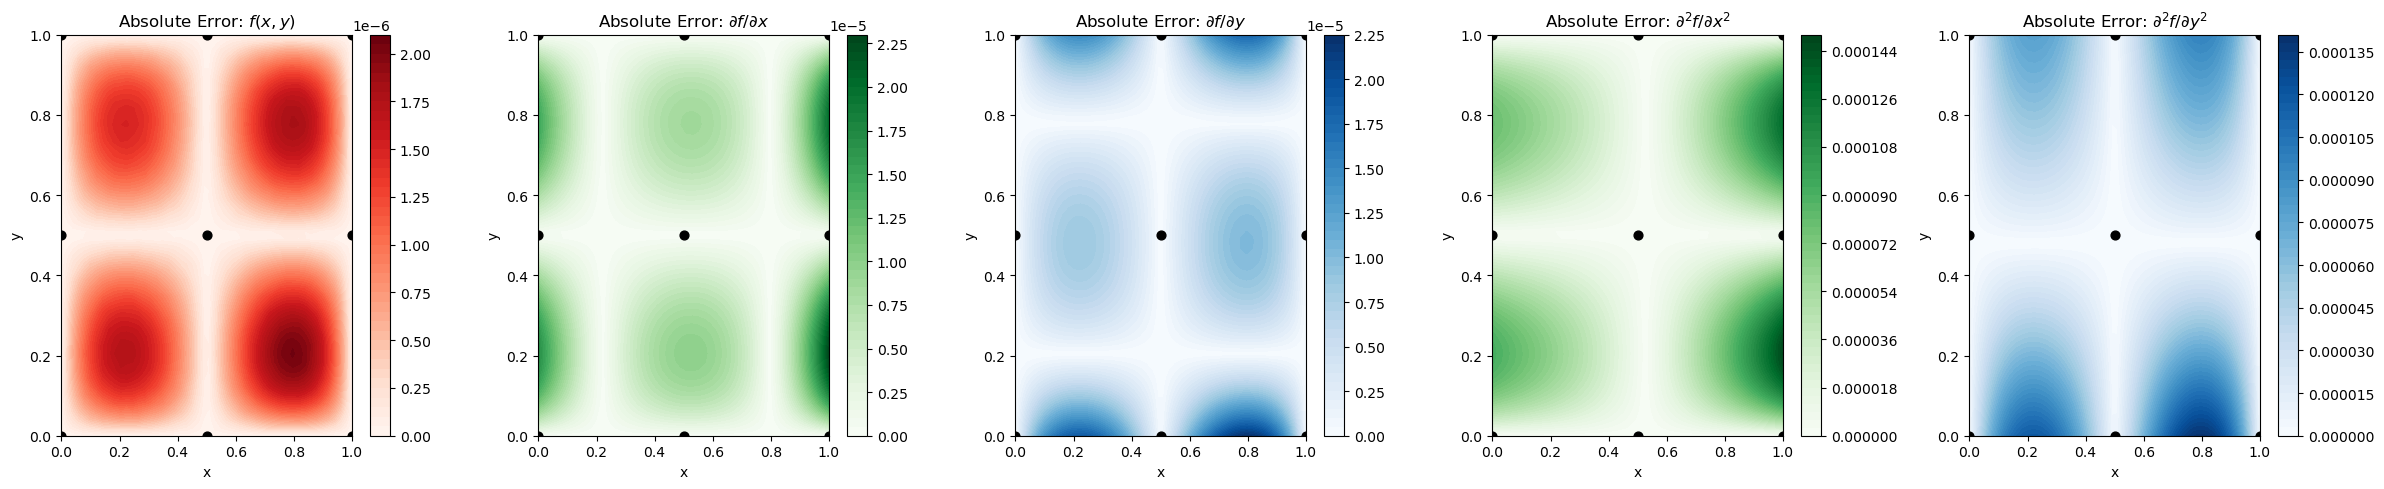

In [31]:
import matplotlib.pyplot as plt

# Compute absolute errors
abs_error_func = np.abs(y_func_test - (np.sin(X1_test) * np.cos(X2_test)))
abs_error_dx   = np.abs(y_deriv_x_test - (np.cos(X1_test) * np.cos(X2_test)))
abs_error_dy   = np.abs(y_deriv_y_test - (-np.sin(X1_test) * np.sin(X2_test)))
abs_error_xx   = np.abs(y_deriv_xx_test - (-np.sin(X1_test) * np.cos(X2_test)))
abs_error_yy   = np.abs(y_deriv_yy_test - (-np.sin(X1_test) * np.cos(X2_test)))

# Setup figure
fig, axs = plt.subplots(1, 5, figsize=(24, 5))

# Titles and errors
titles = [
   r'Absolute Error: $f(x,y)$',
   r'Absolute Error: $\partial f / \partial x$',
   r'Absolute Error: $\partial f / \partial y$',
   r'Absolute Error: $\partial^2 f / \partial x^2$',
   r'Absolute Error: $\partial^2 f / \partial y^2$'
]

errors = [abs_error_func, abs_error_dx, abs_error_dy, abs_error_xx, abs_error_yy]
cmaps  = ['Reds', 'Greens', 'Blues', 'Greens', 'Blues']

# Plot all
for ax, err, title, cmap in zip(axs, errors, titles, cmaps):
   cs = ax.contourf(X1_test, X2_test, err, levels=50, cmap=cmap)
   ax.scatter(X_train[:,0], X_train[:,1], c='k', s=40)
   ax.set_title(title, fontsize=12)
   ax.set_xlabel('x')
   ax.set_ylabel('y')
   fig.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()